In [1]:
#yaml file
yaml_content = """
train: /kaggle/working/Dataset_split/train/images
val: /kaggle/working/Dataset_split/val/images
test: /kaggle/working/Dataset_split/test/images

nc: 1
names:
  0: fracture
"""

with open("/kaggle/working/data.yaml", "w") as f:
    f.write(yaml_content)



In [2]:
import shutil
import os

src = "/kaggle/input/ped-frac/Dataset_split"
dst = "/kaggle/working/Dataset_split"
if not os.path.exists(dst):
    shutil.copytree(src, dst)


In [ ]:
import cv2
from glob import glob

train_images_path = os.path.join(dst, "train/images")
image_files = glob(os.path.join(train_images_path, "*.png"))  # adjust extension if needed

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

for img_path in image_files:
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  
    cl_img = clahe.apply(img)
    cv2.imwrite(img_path, cl_img)

print("CLAHE applied to all train images.")


CLAHE applied to all train images.


In [4]:
!nvidia-smi  # verify 2 GPUs


Sat Oct 25 11:45:23 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.03              Driver Version: 560.35.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       1MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
!pip install --upgrade ultralytics


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.0 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of mkl-fft to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of mkl-random to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of mkl-umath to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 88.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 91.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 44.5 MB/s eta 0:00:00
   ━━━━━

In [ ]:
from ultralytics import YOLO
model = YOLO("yolo11s.pt")  #import model


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [8]:
results = model.train(
    data="/kaggle/working/data.yaml",
    epochs=50,
    imgsz=512,
    batch=16,
    device="0,1",
    project="/kaggle/working/yolo_results",
    name="fracture_training"
)


Ultralytics 8.3.221 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
                                                       CUDA:1 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=fracture_training, nbs=64, nms=False, opset=None, optimize=

In [9]:
!yolo detect predict \
    model=/kaggle/working/yolo_results/fracture_training/weights/best.pt \
    source=/kaggle/working/Dataset_split/test/images \
    project=/kaggle/working/yolo_results \
    name=fracture_test_predictions \
    save=True


Ultralytics 8.3.221 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11s summary (fused): 100 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs

image 1/1387 /kaggle/working/Dataset_split/test/images/0030_0853281724_01_WRI-L1_F008.png: 512x320 1 fracture, 52.9ms
image 2/1387 /kaggle/working/Dataset_split/test/images/0030_0853281744_01_WRI-L2_F008.png: 512x352 1 fracture, 45.5ms
image 3/1387 /kaggle/working/Dataset_split/test/images/0040_0779044114_04_WRI-L1_M015.png: 512x224 1 fracture, 51.7ms
image 4/1387 /kaggle/working/Dataset_split/test/images/0040_0779044160_04_WRI-L2_M015.png: 512x192 1 fracture, 44.7ms
image 5/1387 /kaggle/working/Dataset_split/test/images/0052_1061971499_01_WRI-R1_F011.png: 512x288 (no detections), 45.1ms
image 6/1387 /kaggle/working/Dataset_split/test/images/0052_1061971533_01_WRI-R2_F011.png: 512x320 (no detections), 9.9ms
image 7/1387 /kaggle/working/Dataset_split/test/images/0056_0422451553_03_WRI-L1_F012.png: 512x288 (no detections),

In [10]:
!yolo detect val \
    model=/kaggle/working/yolo_results/fracture_training/weights/best.pt \
    data=/kaggle/working/data.yaml \
    split=test \
    imgsz=512


Ultralytics 8.3.221 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11s summary (fused): 100 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2406.5±442.1 MB/s, size: 698.4 KB)
val: Scanning /kaggle/working/Dataset_split/test/labels... 1387 images, 756 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1387/1387 228.6it/s 6.1s
val: New cache created: /kaggle/working/Dataset_split/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 87/87 8.0it/s 10.9s
                   all       1387        679      0.952      0.856       0.94      0.553
Speed: 0.5ms preprocess, 3.8ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /kaggle/working/runs/detect/val
💡 Learn more at https://docs.ultralytics.com/modes/val


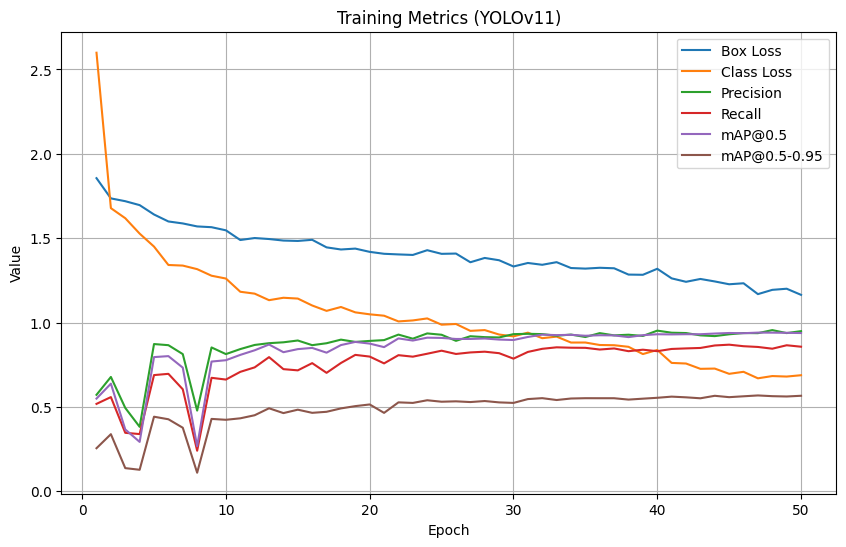

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Path to training results
results_path = "/kaggle/working/yolo_results/fracture_training/results.csv"

# Load results
df = pd.read_csv(results_path)

# Plot curves
plt.figure(figsize=(10,6))
plt.plot(df["epoch"], df["train/box_loss"], label="Box Loss")
plt.plot(df["epoch"], df["train/cls_loss"], label="Class Loss")
plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP@0.5")
plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP@0.5-0.95")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Training Metrics (YOLOv11)")
plt.legend()
plt.grid(True)
plt.show()


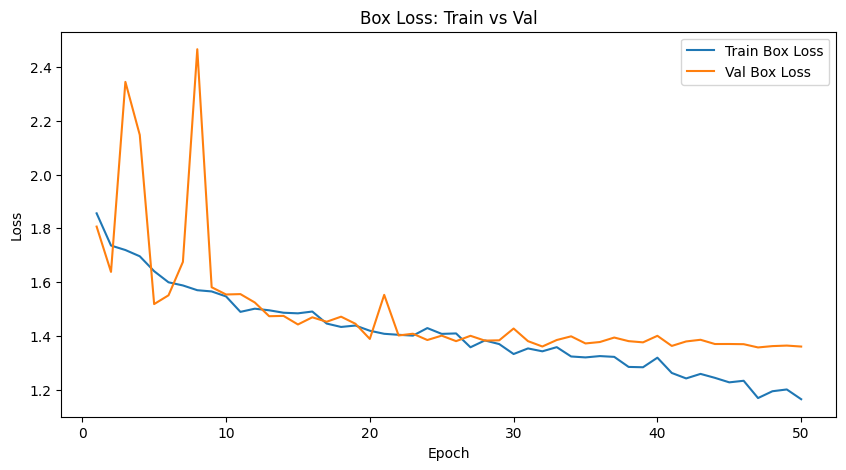

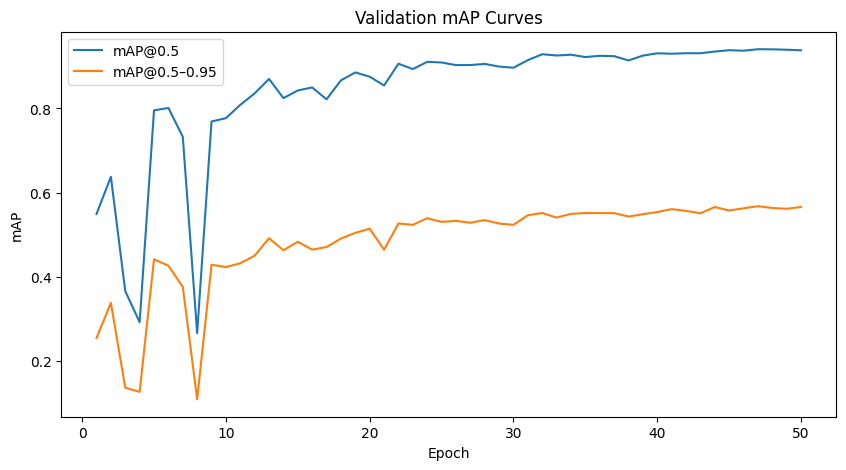

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Load YOLO training log
results = pd.read_csv('/kaggle/working/yolo_results/fracture_training/results.csv')

# Plot train vs val box loss
plt.figure(figsize=(10,5))
plt.plot(results['epoch'], results['train/box_loss'], label='Train Box Loss')
plt.plot(results['epoch'], results['val/box_loss'], label='Val Box Loss')
plt.legend(); plt.title("Box Loss: Train vs Val"); plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.show()

# Plot mAP curve
plt.figure(figsize=(10,5))
plt.plot(results['epoch'], results['metrics/mAP50(B)'], label='mAP@0.5')
plt.plot(results['epoch'], results['metrics/mAP50-95(B)'], label='mAP@0.5–0.95')
plt.legend(); plt.title("Validation mAP Curves"); plt.xlabel("Epoch"); plt.ylabel("mAP")
plt.show()


In [14]:
#inferecing
from ultralytics import YOLO
import torch
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_auc_score, precision_score, recall_score
import numpy as np
import glob
import os

# Load trained model
model = YOLO("/kaggle/working/yolo_results/fracture_training/weights/best.pt")  # path to your best weights

# Folder containing test images
test_dir = "/kaggle/working/Dataset_split/test/images"

# Run inference on test set
results = model.predict(source=test_dir, conf=0.5, save=False, save_txt=False)



WARNING ⚠️ 
inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1387 /kaggle/working/Dataset_split/test/images/0030_0853281724_01_WRI-L1_F008.png: 512x320 1 fracture, 52.6ms
image 2/1387 /kaggle/working/Dataset_split/test/images/0030_0853281744_01_WRI-L2_F008.png: 512x352 1 fracture, 45.3ms
image 3/1387 /kaggle/working/Dataset_split/test/images/0040_0779044114_04_WRI-L1_M015.png: 512x224 1 fracture, 51.2ms
image 4/1387 /kaggle/working/Dataset_split/test/images/0040_0779044160_04_WRI-L2_M015.png: 512x192 1 f

In [15]:
y_true = []
y_pred = []

label_dir = "/kaggle/working/Dataset_split/test/labels"
image_files = sorted(glob.glob(os.path.join(test_dir, "*.png")))

for r in results:
    img_path = r.path
    img_name = os.path.basename(img_path).replace(".png", ".txt")
    gt_path = os.path.join(label_dir, img_name)

    # Ground truth classes
    if os.path.exists(gt_path):
        with open(gt_path, "r") as f:
            gt_classes = [int(line.split()[0]) for line in f.readlines()]
    else:
        gt_classes = []

    # Predicted classes
    pred_classes = r.boxes.cls.cpu().numpy().astype(int)

    # Append (assuming binary or single-label per image for simplicity)
    y_true.append(1 if len(gt_classes) > 0 else 0)
    y_pred.append(1 if len(pred_classes) > 0 else 0)


In [16]:
# Convert to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Basic metrics
acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)  # same as sensitivity

# Specificity
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
specificity = tn / (tn + fp)

# AUC (works for binary)
auc = roc_auc_score(y_true, y_pred)

print(f"Accuracy: {acc:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall (Sensitivity): {recall:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"F1 Score: {f1:.3f}")
print(f"AUC: {auc:.3f}")


Accuracy: 0.937
Precision: 0.998
Recall (Sensitivity): 0.862
Specificity: 0.999
F1 Score: 0.925
AUC: 0.930


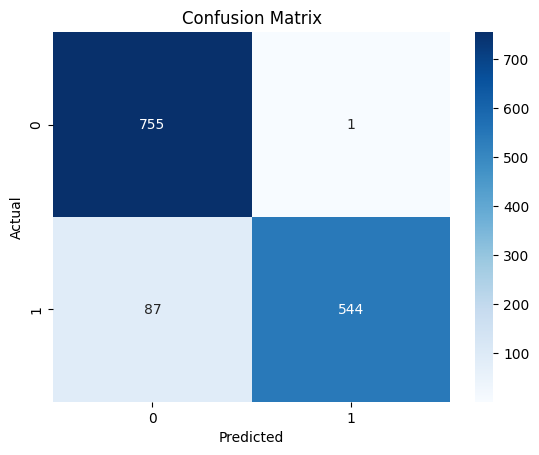

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
